# Migration Fear Index - Exploratory Data Analysis

This notebook explores the Migration Fear Index dataset covering multiple countries.

**Dataset:** `migration-fear.xlsx`

**Description:** Quarterly migration-related EPU and fear indices for UK, Germany, USA, and France from 1990 onwards.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)

DATA_PATH = Path('../../../data/raw/migration-fear.xlsx')
CSV_OUTPUT_PATH = Path('../../../data/raw/migration-fear.csv')

## 1. Load and Clean Data

In [2]:
# Load Excel file
df = pd.read_excel(DATA_PATH)

print("Raw data (first 10 rows):")
display(df.head(10))

# Clean column names
df.columns = df.columns.str.strip()

# Create date column from year and quarter
df['date'] = pd.to_datetime(df['year'].astype(str) + '-' + ((df['quarter'] - 1) * 3 + 1).astype(str) + '-01')

# Sort by date
df = df.sort_values('date').reset_index(drop=True)

print("\nCleaned dataset:")
display(df.head())
print("\nData types:")
print(df.dtypes)
print("\nColumn names:")
print(df.columns.tolist())

Raw data (first 10 rows):


,year,quarter,uk_epu_migrant_index,uk_fear_index,germany_epu_migrant_index,germany_fear_index,usa_epu_migrant_index,usa_fear_index,france_epu_migrant_index,france_fear_index
0,1990,1,25.029695,67.404421,112.338247,21.229359,110.983753,89.928741,61.428726,80.199609
1,1990,2,22.545424,56.605845,118.174000,44.664365,71.965496,84.918389,112.014560,72.055611
2,1990,3,51.420031,66.113057,114.698294,68.122541,91.554059,96.256257,94.260273,103.976142
3,1990,4,25.513361,43.910439,98.727645,53.306476,115.441072,85.235934,31.166537,4.982467
4,1991,1,53.821816,61.027777,115.101310,52.825107,83.590287,99.320696,66.425833,83.183949
5,1991,2,24.862765,91.119050,105.875348,48.590903,98.801078,112.656726,57.417810,87.584404
6,1991,3,26.351430,63.493947,124.176773,60.342607,76.977136,84.732399,46.471081,69.338664
7,1991,4,81.986013,86.875906,290.749995,73.260131,129.645122,91.575756,65.306403,86.567229
8,1992,1,25.647587,66.471835,122.688512,59.619400,141.434584,90.258963,116.000872,94.268318
9,1992,2,24.469185,69.858586,348.734912,37.658812,109.485076,89.241337,173.449304,74.363155



Cleaned dataset:


,year,quarter,uk_epu_migrant_index,uk_fear_index,germany_epu_migrant_index,germany_fear_index,usa_epu_migrant_index,usa_fear_index,france_epu_migrant_index,france_fear_index,date
0,1990,1,25.029695,67.404421,112.338247,21.229359,110.983753,89.928741,61.428726,80.199609,1990-01-01
1,1990,2,22.545424,56.605845,118.174000,44.664365,71.965496,84.918389,112.014560,72.055611,1990-04-01
2,1990,3,51.420031,66.113057,114.698294,68.122541,91.554059,96.256257,94.260273,103.976142,1990-07-01
3,1990,4,25.513361,43.910439,98.727645,53.306476,115.441072,85.235934,31.166537,4.982467,1990-10-01
4,1991,1,53.821816,61.027777,115.101310,52.825107,83.590287,99.320696,66.425833,83.183949,1991-01-01



Data types:
year                                  int64
quarter                               int64
uk_epu_migrant_index                float64
uk_fear_index                       float64
germany_epu_migrant_index           float64
germany_fear_index                  float64
usa_epu_migrant_index               float64
usa_fear_index                      float64
france_epu_migrant_index            float64
france_fear_index                   float64
date                         datetime64[ns]
dtype: object

Column names:
['year', 'quarter', 'uk_epu_migrant_index', 'uk_fear_index', 'germany_epu_migrant_index', 'germany_fear_index', 'usa_epu_migrant_index', 'usa_fear_index', 'france_epu_migrant_index', 'france_fear_index', 'date']


## 2. Save to CSV

In [3]:
# Save cleaned data to CSV
df.to_csv(CSV_OUTPUT_PATH, index=False)
print(f"✓ Data saved to: {CSV_OUTPUT_PATH}")
print(f"  Rows saved: {len(df)}")

✓ Data saved to: ../../data/raw/migration-fear.csv
  Rows saved: 144


## 3. Data Overview

In [4]:
print("Dataset Shape:", df.shape)
print("\nDate range:", df['date'].min(), "to", df['date'].max())
print("Total quarters:", len(df))
print("\nDataset Info:")
df.info()

Dataset Shape: (144, 11)

Date range: 1990-01-01 00:00:00 to 2025-10-01 00:00:00
Total quarters: 144

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 11 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   year                       144 non-null    int64         
 1   quarter                    144 non-null    int64         
 2   uk_epu_migrant_index       144 non-null    float64       
 3   uk_fear_index              144 non-null    float64       
 4   germany_epu_migrant_index  144 non-null    float64       
 5   germany_fear_index         144 non-null    float64       
 6   usa_epu_migrant_index      144 non-null    float64       
 7   usa_fear_index             144 non-null    float64       
 8   france_epu_migrant_index   120 non-null    float64       
 9   france_fear_index          120 non-null    float64       
 10  date              

## 4. Missing Values

In [5]:
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({'Missing Count': missing, 'Percentage': missing_pct})
print("Missing Values Summary:")
display(missing_df[missing_df['Missing Count'] > 0])

Missing Values Summary:


,Missing Count,Percentage
france_epu_migrant_index,24,16.666667
france_fear_index,24,16.666667


## 5. Descriptive Statistics

In [6]:
# Get all index columns (excluding year, quarter, date)
index_cols = [col for col in df.columns if col not in ['year', 'quarter', 'date']]

print("Descriptive Statistics:")
display(df[index_cols].describe())

Descriptive Statistics:


,uk_epu_migrant_index,uk_fear_index,germany_epu_migrant_index,germany_fear_index,usa_epu_migrant_index,usa_fear_index,france_epu_migrant_index,france_fear_index
count,144.000000,144.000000,144.000000,144.000000,144.000000,144.000000,120.000000,120.000000
mean,459.805316,196.111075,211.714585,251.964786,219.648911,119.471359,146.314967,123.442027
std,639.074771,137.311079,227.242461,239.290665,296.284765,54.941913,110.819716,62.272331
min,8.613685,40.113758,16.793721,21.229359,32.679280,61.088917,6.614144,4.982467
25%,50.376275,82.195807,58.479793,92.885232,80.686296,88.098706,66.145976,76.998772
50%,192.166061,153.440338,113.880151,128.953298,126.218044,102.703461,119.024058,117.179572
75%,653.169931,292.746603,293.402498,417.564826,233.742536,128.438916,194.194007,147.696579
max,3041.704852,571.934745,1352.807377,1277.676403,2067.930465,359.036117,585.145023,349.561970


## 6. Time Series - EPU Migrant Indices

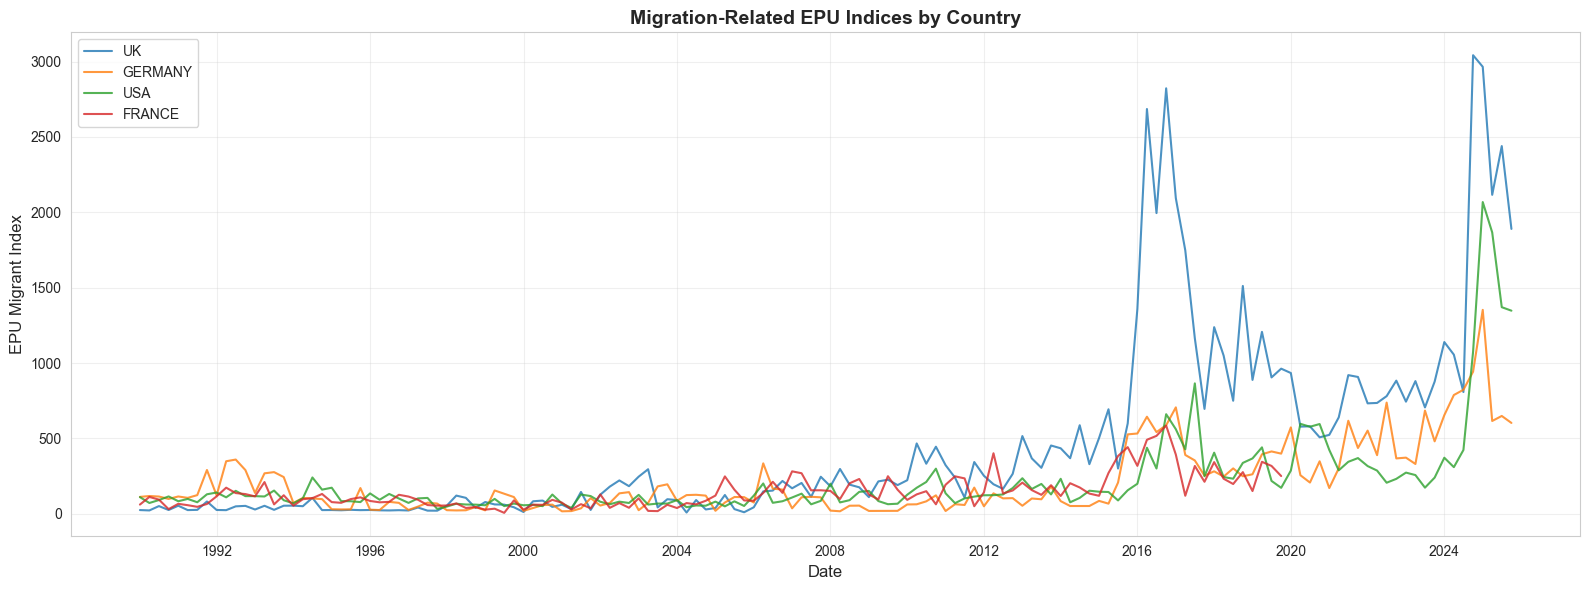

In [7]:
# Plot EPU migrant indices for all countries
epu_cols = [col for col in df.columns if 'epu_migrant' in col]

fig, ax = plt.subplots(figsize=(16, 6))
for col in epu_cols:
    country = col.split('_')[0].upper()
    ax.plot(df['date'], df[col], linewidth=1.5, label=country, alpha=0.8)

ax.set_title('Migration-Related EPU Indices by Country', fontsize=14, fontweight='bold')
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('EPU Migrant Index', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Time Series - Fear Indices

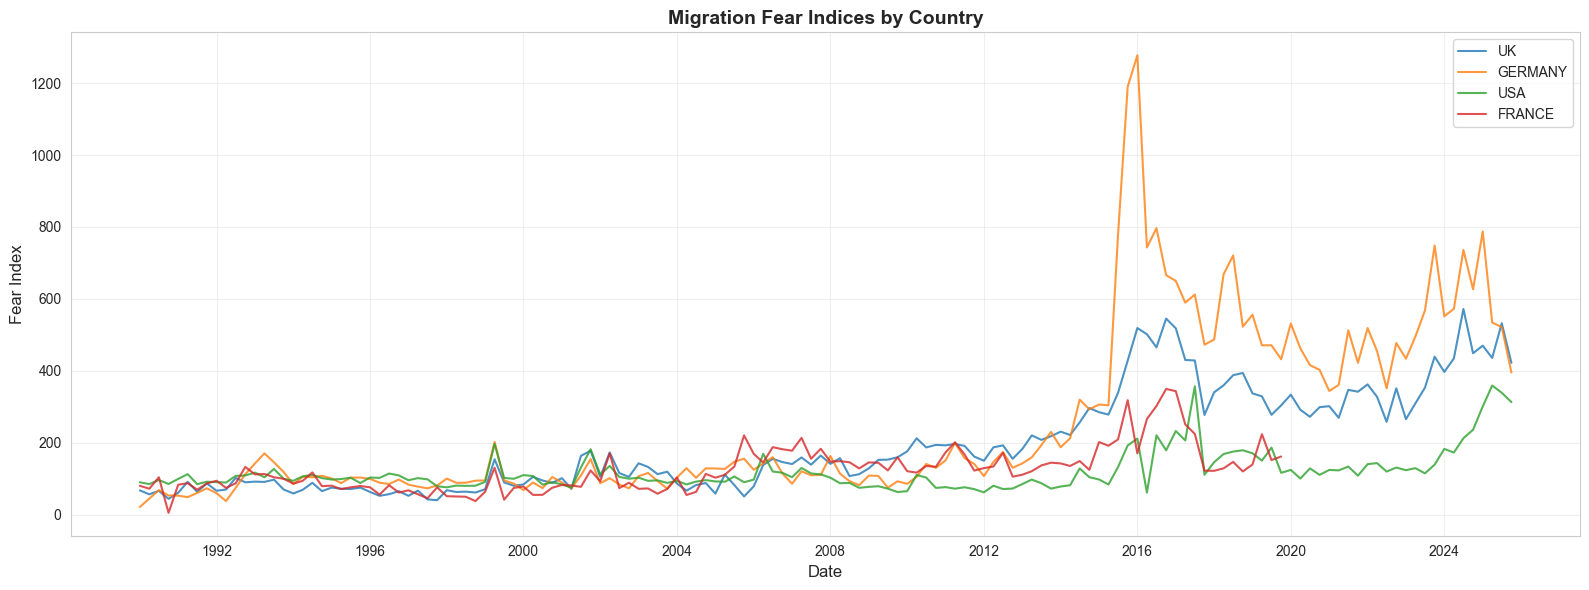

In [8]:
# Plot fear indices for all countries
fear_cols = [col for col in df.columns if 'fear' in col]

fig, ax = plt.subplots(figsize=(16, 6))
for col in fear_cols:
    country = col.split('_')[0].upper()
    ax.plot(df['date'], df[col], linewidth=1.5, label=country, alpha=0.8)

ax.set_title('Migration Fear Indices by Country', fontsize=14, fontweight='bold')
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Fear Index', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 8. Country-by-Country Analysis

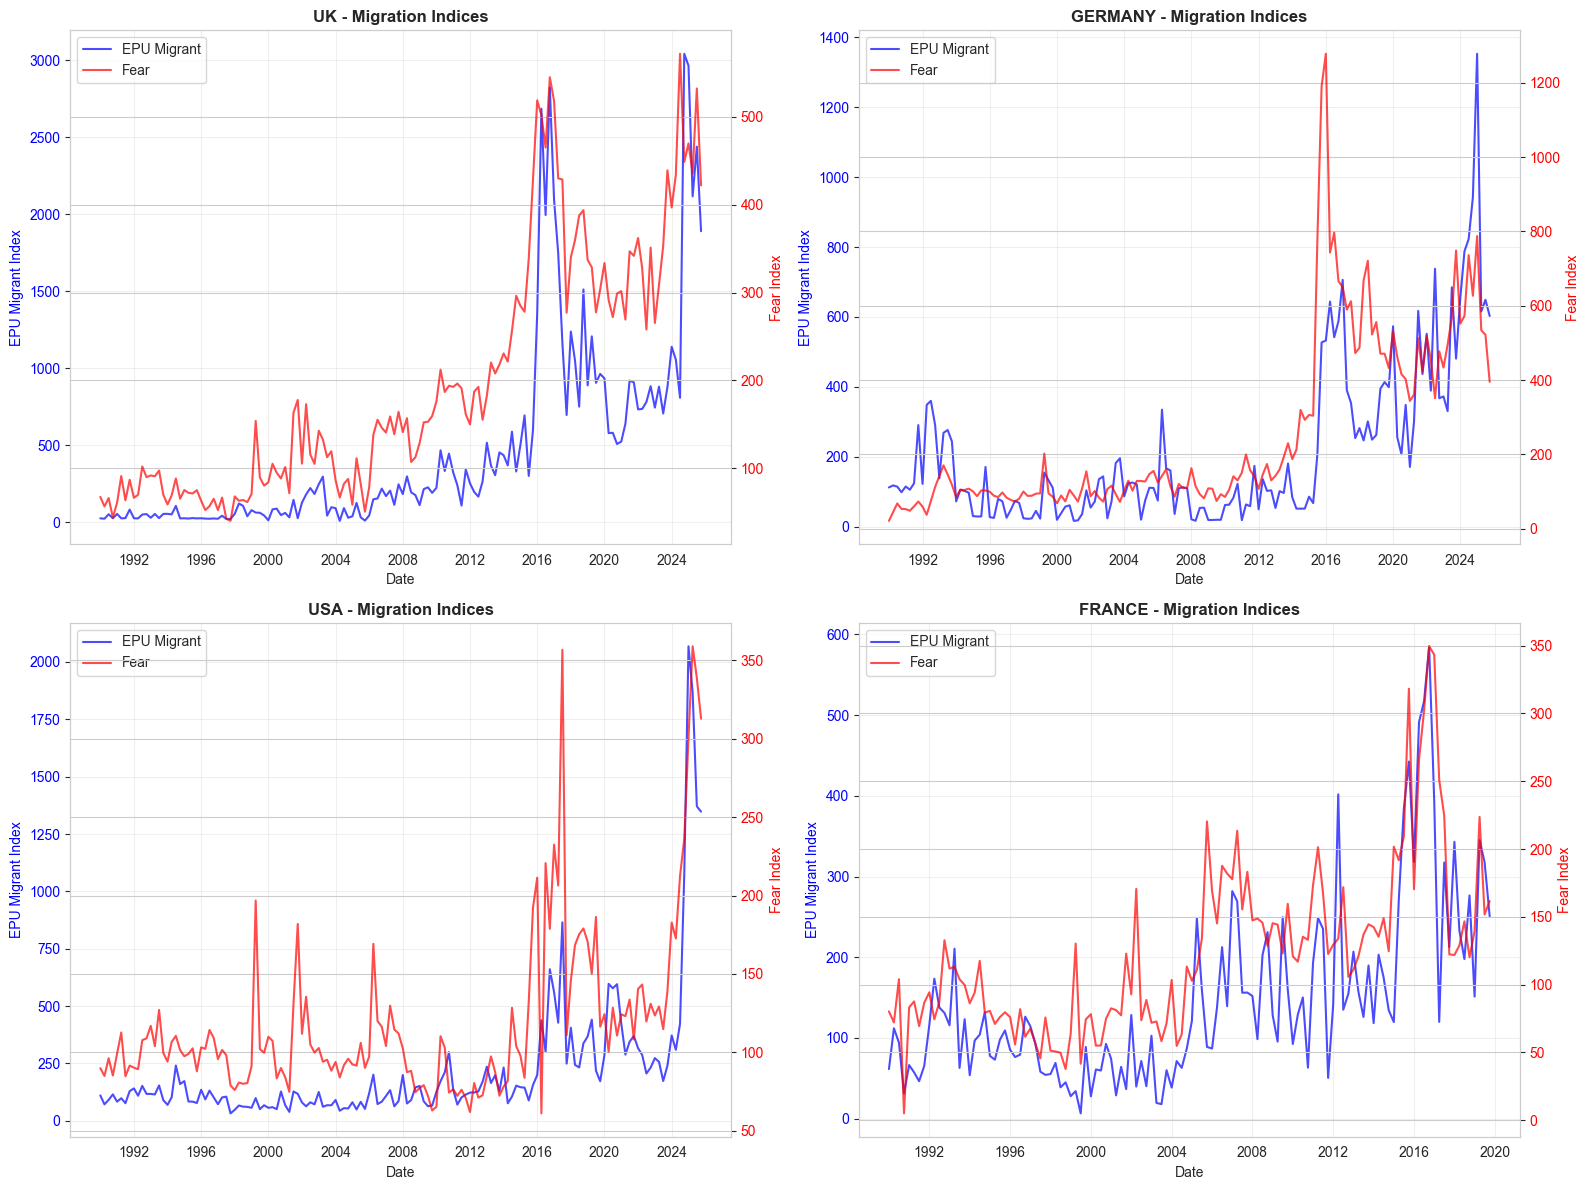

In [9]:
# Create subplots for each country
countries = ['uk', 'germany', 'usa', 'france']

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for idx, country in enumerate(countries):
    epu_col = f'{country}_epu_migrant_index'
    fear_col = f'{country}_fear_index'
    
    ax = axes[idx]
    ax2 = ax.twinx()
    
    # Plot EPU on left axis
    line1 = ax.plot(df['date'], df[epu_col], color='blue', linewidth=1.5, label='EPU Migrant', alpha=0.7)
    ax.set_ylabel('EPU Migrant Index', color='blue', fontsize=10)
    ax.tick_params(axis='y', labelcolor='blue')
    
    # Plot Fear on right axis
    line2 = ax2.plot(df['date'], df[fear_col], color='red', linewidth=1.5, label='Fear', alpha=0.7)
    ax2.set_ylabel('Fear Index', color='red', fontsize=10)
    ax2.tick_params(axis='y', labelcolor='red')
    
    ax.set_title(f'{country.upper()} - Migration Indices', fontsize=12, fontweight='bold')
    ax.set_xlabel('Date', fontsize=10)
    ax.grid(True, alpha=0.3)
    
    # Combine legends
    lines = line1 + line2
    labels = [l.get_label() for l in lines]
    ax.legend(lines, labels, loc='upper left')

plt.tight_layout()
plt.show()

## 9. Correlation Analysis

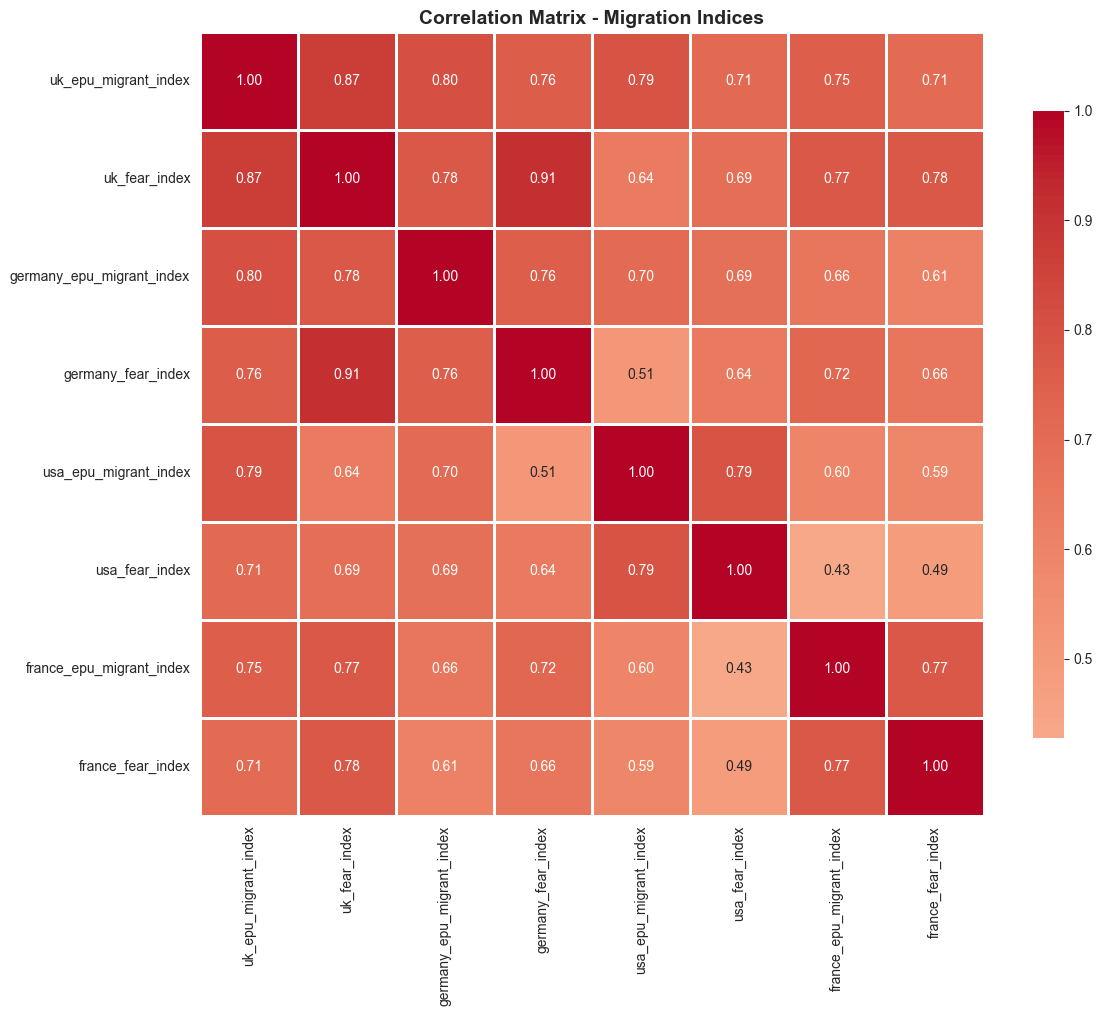

In [10]:
# Correlation matrix
corr_matrix = df[index_cols].corr()

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8}, ax=ax)
ax.set_title('Correlation Matrix - Migration Indices', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 10. Distribution Comparison

/var/folders/yb/9z2xfdzs0r73bc0dr86m_tdc0000gn/T/ipykernel_95209/391816360.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot(epu_data, labels=epu_labels)
/var/folders/yb/9z2xfdzs0r73bc0dr86m_tdc0000gn/T/ipykernel_95209/391816360.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(fear_data, labels=fear_labels)


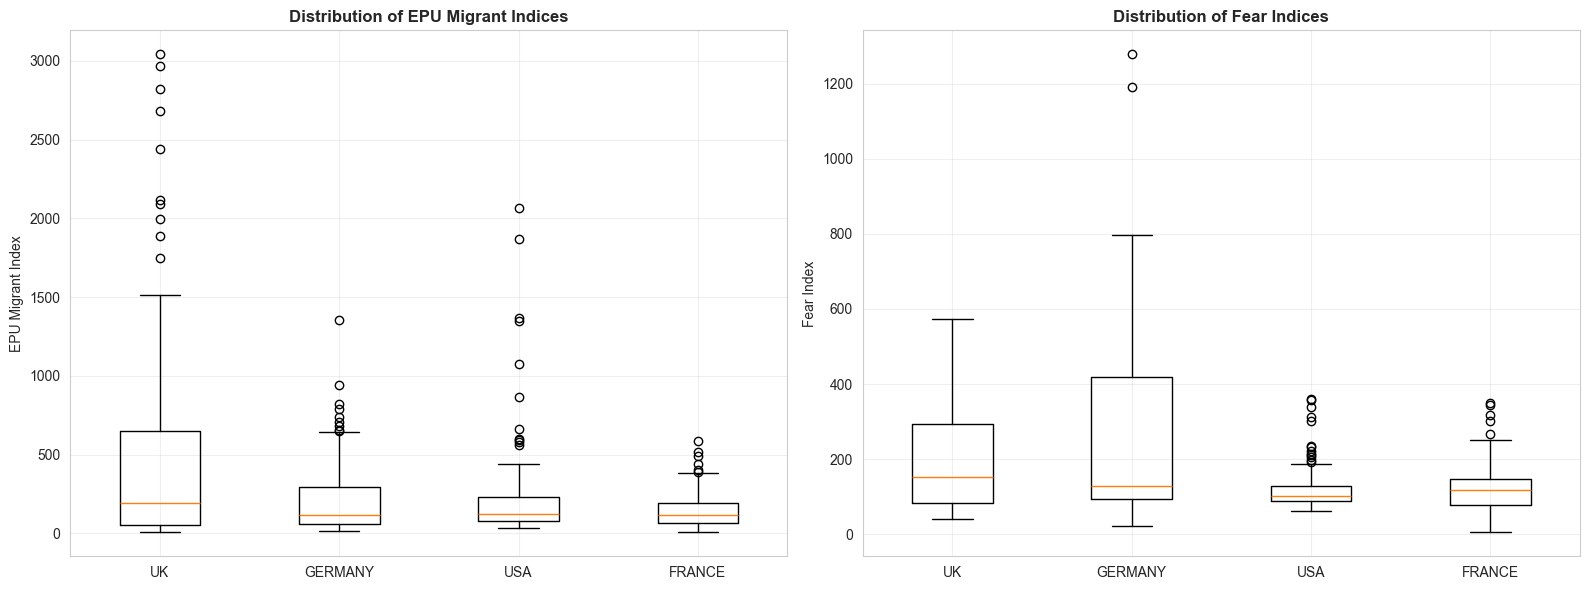

In [11]:
# Box plots for EPU indices
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# EPU Migrant Indices
epu_data = [df[col].dropna() for col in epu_cols]
epu_labels = [col.split('_')[0].upper() for col in epu_cols]
axes[0].boxplot(epu_data, labels=epu_labels)
axes[0].set_title('Distribution of EPU Migrant Indices', fontsize=12, fontweight='bold')
axes[0].set_ylabel('EPU Migrant Index')
axes[0].grid(True, alpha=0.3)

# Fear Indices
fear_data = [df[col].dropna() for col in fear_cols]
fear_labels = [col.split('_')[0].upper() for col in fear_cols]
axes[1].boxplot(fear_data, labels=fear_labels)
axes[1].set_title('Distribution of Fear Indices', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Fear Index')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 11. Summary Statistics by Country

In [12]:
# Summary statistics for each country
for country in countries:
    epu_col = f'{country}_epu_migrant_index'
    fear_col = f'{country}_fear_index'
    
    print(f"\n{'='*60}")
    print(f"{country.upper()} - Summary Statistics")
    print(f"{'='*60}")
    
    print(f"\nEPU Migrant Index:")
    print(f"  Mean: {df[epu_col].mean():.2f}")
    print(f"  Median: {df[epu_col].median():.2f}")
    print(f"  Std Dev: {df[epu_col].std():.2f}")
    print(f"  Min: {df[epu_col].min():.2f}")
    print(f"  Max: {df[epu_col].max():.2f}")
    
    print(f"\nFear Index:")
    print(f"  Mean: {df[fear_col].mean():.2f}")
    print(f"  Median: {df[fear_col].median():.2f}")
    print(f"  Std Dev: {df[fear_col].std():.2f}")
    print(f"  Min: {df[fear_col].min():.2f}")
    print(f"  Max: {df[fear_col].max():.2f}")
    
    # Correlation between EPU and Fear for this country
    corr = df[[epu_col, fear_col]].corr().iloc[0, 1]
    print(f"\nCorrelation (EPU vs Fear): {corr:.3f}")


UK - Summary Statistics

EPU Migrant Index:
  Mean: 459.81
  Median: 192.17
  Std Dev: 639.07
  Min: 8.61
  Max: 3041.70

Fear Index:
  Mean: 196.11
  Median: 153.44
  Std Dev: 137.31
  Min: 40.11
  Max: 571.93

Correlation (EPU vs Fear): 0.870

GERMANY - Summary Statistics

EPU Migrant Index:
  Mean: 211.71
  Median: 113.88
  Std Dev: 227.24
  Min: 16.79
  Max: 1352.81

Fear Index:
  Mean: 251.96
  Median: 128.95
  Std Dev: 239.29
  Min: 21.23
  Max: 1277.68

Correlation (EPU vs Fear): 0.758

USA - Summary Statistics

EPU Migrant Index:
  Mean: 219.65
  Median: 126.22
  Std Dev: 296.28
  Min: 32.68
  Max: 2067.93

Fear Index:
  Mean: 119.47
  Median: 102.70
  Std Dev: 54.94
  Min: 61.09
  Max: 359.04

Correlation (EPU vs Fear): 0.794

FRANCE - Summary Statistics

EPU Migrant Index:
  Mean: 146.31
  Median: 119.02
  Std Dev: 110.82
  Min: 6.61
  Max: 585.15

Fear Index:
  Mean: 123.44
  Median: 117.18
  Std Dev: 62.27
  Min: 4.98
  Max: 349.56

Correlation (EPU vs Fear): 0.773


## 12. Summary

In [13]:
print("=" * 60)
print("KEY FINDINGS - MIGRATION FEAR INDEX")
print("=" * 60)
print(f"\n1. Dataset Coverage:")
print(f"   - Start: {df['date'].min().strftime('%Y-Q%q')}")
print(f"   - End: {df['date'].max().strftime('%Y-Q%q')}")
print(f"   - Total Quarters: {len(df)}")
print(f"   - Countries: UK, Germany, USA, France")

print(f"\n2. Indices Tracked:")
print(f"   - EPU Migrant Index (4 countries)")
print(f"   - Fear Index (4 countries)")
print(f"   - Total: {len(index_cols)} indices")

print(f"\n3. Data Quality:")
print(f"   - Total Missing Values: {df[index_cols].isnull().sum().sum()}")
print(f"   - CSV file saved: {CSV_OUTPUT_PATH}")

print(f"\n4. Cross-Country Insights:")
# Find country with highest average EPU
avg_epu = {country: df[f'{country}_epu_migrant_index'].mean() for country in countries}
max_epu_country = max(avg_epu, key=avg_epu.get)
print(f"   - Highest avg EPU: {max_epu_country.upper()} ({avg_epu[max_epu_country]:.2f})")

# Find country with highest average Fear
avg_fear = {country: df[f'{country}_fear_index'].mean() for country in countries}
max_fear_country = max(avg_fear, key=avg_fear.get)
print(f"   - Highest avg Fear: {max_fear_country.upper()} ({avg_fear[max_fear_country]:.2f})")

print("\n" + "=" * 60)

KEY FINDINGS - MIGRATION FEAR INDEX

1. Dataset Coverage:
   - Start: 1990-Qq
   - End: 2025-Qq
   - Total Quarters: 144
   - Countries: UK, Germany, USA, France

2. Indices Tracked:
   - EPU Migrant Index (4 countries)
   - Fear Index (4 countries)
   - Total: 8 indices

3. Data Quality:
   - Total Missing Values: 48
   - CSV file saved: ../../data/raw/migration-fear.csv

4. Cross-Country Insights:
   - Highest avg EPU: UK (459.81)
   - Highest avg Fear: GERMANY (251.96)

